In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Rectangle

In [3]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

In [19]:
XXSMALL_SIZE = 10
XSMALL_SIZE = 12
SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=XSMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=XSMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=XSMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=XSMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## K-mer occurrence probability

In [5]:
alphabet_size = 4
def distinct_kmer_count(k):
    return alphabet_size**k

def vanilla_kmer_occ_prob(k, bin_size):
    return min(1.0, bin_size / distinct_kmer_count(k))

def recursive_kmer_hit_placement_count(seq_len, k, kmer_hits):
    if (seq_len - k * kmer_hits < 0):
        return 0
    elif (kmer_hits > 1):
        count = 0
        for free_positions in range(k * (kmer_hits - 1), seq_len - k + 1):
            count += recursive_kmer_hit_placement_count(free_positions, k, kmer_hits - 1)
        return count
    else:
        return seq_len - k + 1

def kmer_hit_placement_count(seq_len, k, kmer_hits):
    if (kmer_hits == 0):
        return 0
    elif (kmer_hits == 1):
        return seq_len - k + 1
    else:
        count_table = []
        for h in range(1, kmer_hits + 1):
            row = []
            for l in range(1, seq_len + 1):
                if (l < k * h):
                    row.append(0)
                elif (h == 1):
                    row.append(l - k + 1)
                else:
                    #print(str(h) + "\t" + str(l) + "\t" + str(k * (h - 1) - 1))
                    #print(count_table[-1][k * (h - 1) - 1:l - k])
                    row.append(sum(count_table[-1][k * (h - 1) - 1:l - k]))
            
            count_table.append(row)

    #for row in count_table:
    #    print(row)
    return count_table[kmer_hits - 1][seq_len - 1]
        
def distinct_seq_count(seq_len, k, kmer_hits):
    free_positions = seq_len - k * kmer_hits
    return alphabet_size**free_positions

def swenja_kmer_occ_prob(k, bin_size):
    kmer_prob_numerator = 0
    max_hits = bin_size // k
    
    for kmer_hits in range(1, max_hits + 1, 1):
        # combinations among n+1 kmer hits
        comb_multiplier = max(1, math.comb(kmer_hits, kmer_hits - 1) - 1)
        # Set the position of the k-mers in the bin
        # ATCxxxATCxxx
        # Find the number of distinct sequences with this placement of k-mer hits
        dist_seq_count = distinct_seq_count(bin_size, k, kmer_hits)
        # Find all possible placements of k-mer hits
        # ATCATCxxxxxx
        # ATCxATCxxxxx
        # .
        # .
        # .
        # xxxxxxATCATC
        kmer_hit_placements = kmer_hit_placement_count(bin_size, k, kmer_hits) 

        #print("comb_multiplier\t" + str(comb_multiplier) )
        #print("dist_seq_count\t" + str(dist_seq_count) )
        #print("kmer_hit_placements\t" + str(kmer_hit_placements))
        
        ith_union = comb_multiplier * dist_seq_count * kmer_hit_placements

        #print(ith_union)
        if (kmer_hits % 2 == 0):
            kmer_prob_numerator -= ith_union
        else: 
            kmer_prob_numerator += ith_union

        #print(kmer_prob_numerator)
        
    #print(str(max_kmers) + "\t" + str(bin_size) + "\t" + str(kmer_occ_prob))
    return kmer_prob_numerator / alphabet_size**bin_size

def recursive_swenja_kmer_occ_prob(k, bin_size):
    kmer_prob_numerator = 0
    max_hits = bin_size // k
    
    for kmer_hits in range(1, max_hits + 1, 1):
        # combinations among n+1 kmer hits
        comb_multiplier = max(1, math.comb(kmer_hits, kmer_hits - 1) - 1)
        # Set the position of the k-mers in the bin
        # ATCxxxATCxxx
        # Find the number of distinct sequences with this placement of k-mer hits
        dist_seq_count = distinct_seq_count(bin_size, k, kmer_hits)
        # Find all possible placements of k-mer hits
        # ATCATCxxxxxx
        # ATCxATCxxxxx
        # .
        # .
        # .
        # xxxxxxATCATC
        kmer_hit_placements = recursive_kmer_hit_placement_count(bin_size, k, kmer_hits) 

        #print("comb_multiplier\t" + str(comb_multiplier) )
        #print("dist_seq_count\t" + str(dist_seq_count) )
        #print("kmer_hit_placements\t" + str(kmer_hit_placements))
        
        ith_union = comb_multiplier * dist_seq_count * kmer_hit_placements

        #print(ith_union)
        if (kmer_hits % 2 == 0):
            kmer_prob_numerator -= ith_union
        else: 
            kmer_prob_numerator += ith_union

        #print(kmer_prob_numerator)
        
    #print(str(max_kmers) + "\t" + str(bin_size) + "\t" + str(kmer_occ_prob))
    return kmer_prob_numerator / alphabet_size**bin_size

In [6]:
%%time
print(recursive_swenja_kmer_occ_prob(4, 20))

0.06503732083729119
CPU times: user 70 µs, sys: 48 µs, total: 118 µs
Wall time: 122 µs


In [7]:
%%time
print(swenja_kmer_occ_prob(4, 50))

0.17037931242810453
CPU times: user 6.69 ms, sys: 398 µs, total: 7.08 ms
Wall time: 6.26 ms


In [8]:
%%time
print(vanilla_kmer_occ_prob(4, 100))

0.390625
CPU times: user 232 µs, sys: 0 ns, total: 232 µs
Wall time: 197 µs


In [9]:
#https://stackoverflow.com/questions/6790620/probability-of-3-character-string-appearing-in-a-randomly-generated-password
bin_size = 20
vanilla_p = []
swenja_p = []
k = 11
for i in range(10):
    vanilla_p.append(vanilla_kmer_occ_prob(k, bin_size))
    swenja_p.append(swenja_kmer_occ_prob(k, bin_size))
    bin_size += 1024

KeyboardInterrupt: 

In [ ]:
vanilla_p

In [ ]:
swenja_p

## Objective function

In [10]:
err_list = [0, 3, 2, 4, 5]

def find_FPR(pattern_p):
    none_match_p = (1 - pattern_p)**patterns_per_segment
    return min(1 - none_match_p, 1)

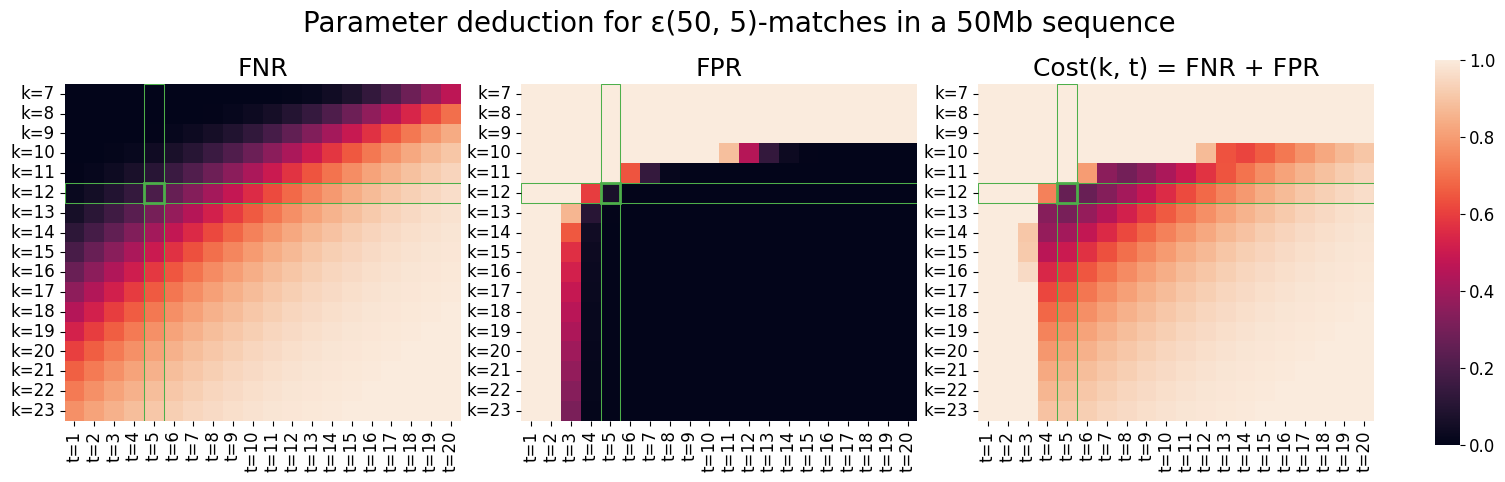

In [37]:
er = 10
l = 50
d = "50Mb"

fig, axs = plt.subplots(1,4, width_ratios = [16, 16, 16, 1])
fig.suptitle('Parameter deduction for ε(50, 5)-matches in a 50Mb sequence', fontsize=BIGGER_SIZE)
fig.set_size_inches(18, 5)
#fig.suptitle('Query k-mer thresholds')

#for i in range(3):
#    axs[i].set_box_aspect(1)

fnr_df = pd.read_csv(d + '/fnr_e' + str(er) + '.l' + str(l) + '.tsv', sep='\t', index_col=0)
fnr_df = fnr_df.iloc[:, :-1]
#fnr_df.columns = fnr_df.columns.str.lstrip('t=')
#fnr_df.index = fnr_df.index.str.lstrip('k=')

sns.heatmap(fnr_df, ax = axs[0], vmin=0, vmax=1, square = True, cbar = False)
axs[0].set_title("FNR")

# these are the false positive probabilities of a pattern appearing in a reference bin
pattern_fp_df = pd.read_csv(d + '/fpr_e' + str(er) + '.l' + str(l) + '.tsv', sep='\t', index_col=0)
pattern_fp_df = pattern_fp_df.iloc[:, :-1]    

# recreation of FPR calculation in filtering_request.hpp
query_len = 50 * 1024 * 1024
query_seg_count = 170000
pattern = l
query_every = 2
patterns_per_segment = (query_len / query_seg_count - pattern + 1) / query_every  
patterns_per_segment = 1000
fpr_df = pattern_fp_df.map(find_FPR)
#fpr_df.columns = fpr_df.columns.str.lstrip('t=')
#fpr_df.index = fpr_df.index.str.lstrip('k=')

sns.heatmap(fpr_df, ax = axs[1], vmin=0, vmax=1, square = True, cbar = False)    
axs[1].set_title("FPR")

#axs[1].get_yaxis().set_visible(False)
#axs[2].get_yaxis().set_visible(False)

score_df = fnr_df + fpr_df
sns.heatmap(score_df, ax = axs[2], vmin=0, vmax=1, square = True, cbar_ax = axs[3])
axs[2].set_title("Cost(k, t) = FNR + FPR")

for i in range(3):
    #axs[i].set_ylabel("k-mer weight")
    #axs[i].set_xlabel("threshold")
    axs[i].add_patch(Rectangle((4, 0), 1, 18, fill=False, edgecolor=CB_color_cycle[2], lw=0.75))
    axs[i].add_patch(Rectangle((0, 5), 20, 1, fill=False, edgecolor=CB_color_cycle[2], lw=0.75))
    axs[i].add_patch(Rectangle((4, 5), 1, 1, fill=False, edgecolor=CB_color_cycle[2], lw=2))

fig.savefig("50Mb." + str(er) + 'e.' + str(l) + 'l.heatmap.svg', dpi=400, bbox_inches='tight')
plt.show()

In [39]:
fnr_df

,t=1,t=2,t=3,t=4,t=5,t=6,t=7,t=8,t=9,t=10,t=11,t=12,t=13,t=14,t=15,t=16,t=17,t=18,t=19,t=20
k=7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000945,0.003780,0.010222,0.022677,0.044383,0.079530,0.133375,0.198649,0.277459,0.367691,0.465605
k=8,0.000000,0.000000,0.000000,0.000026,0.000225,0.000978,0.003026,0.007586,0.016466,0.032192,0.058121,0.094694,0.143425,0.204639,0.277587,0.360215,0.448923,0.538324,0.621012,0.698223
k=9,0.000026,0.000225,0.000978,0.003026,0.007586,0.016466,0.031598,0.054892,0.087983,0.131985,0.187262,0.253188,0.327904,0.408088,0.488710,0.568578,0.645038,0.715695,0.778571,0.832263
k=10,0.000945,0.003765,0.010024,0.021531,0.040136,0.067491,0.104813,0.152643,0.210611,0.277197,0.349494,0.425546,0.502822,0.578772,0.650985,0.717344,0.776193,0.826486,0.867954,0.901256
k=11,0.006961,0.018897,0.038564,0.067416,0.106311,0.155277,0.213268,0.278783,0.349834,0.424137,0.499268,0.572826,0.642583,0.706654,0.763645,0.812818,0.854248,0.888980,0.917398,0.940039
k=12,0.025377,0.053540,0.092010,0.140501,0.197990,0.262882,0.333164,0.406565,0.480717,0.553309,0.622251,0.685826,0.742854,0.792851,0.836181,0.872938,0.903423,0.928102,0.947571,0.962512
k=13,0.062158,0.109535,0.166327,0.230821,0.300923,0.374325,0.448656,0.521647,0.591285,0.655973,0.714692,0.767152,0.813098,0.852535,0.885681,0.912938,0.934842,0.952031,0.965202,0.975071
k=14,0.118323,0.182847,0.253504,0.327892,0.403587,0.478305,0.550059,0.617319,0.679166,0.734939,0.784284,0.827116,0.863579,0.894007,0.918885,0.938807,0.954438,0.966477,0.975609,0.982477
k=15,0.190445,0.266922,0.345223,0.422995,0.498223,0.569387,0.635357,0.695364,0.748957,0.795966,0.836461,0.870715,0.899161,0.922354,0.940931,0.955571,0.966958,0.975737,0.982477,0.987631
k=16,0.272680,0.354860,0.434888,0.511107,0.582272,0.647506,0.706267,0.758302,0.803612,0.842408,0.875076,0.902134,0.924194,0.941922,0.955996,0.967071,0.975737,0.982477,0.987631,0.991496


In [31]:
score_df

,t=1,t=2,t=3,t=4,t=5,t=6,t=7,t=8,t=9,t=10,t=11,t=12,t=13,t=14,t=15,t=16,t=17,t=18,t=19,t=20
k=7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000945,1.003780,1.010222,1.022677,1.044383,1.079530,1.133375,1.198649,1.277459,1.367691,1.465605
k=8,1.000000,1.000000,1.000000,1.000026,1.000225,1.000978,1.003026,1.007586,1.016466,1.032192,1.058121,1.094694,1.143425,1.204639,1.277587,1.360215,1.448923,1.538324,1.621012,1.698223
k=9,1.000026,1.000225,1.000978,1.003026,1.007586,1.016466,1.031598,1.054893,1.087983,1.131985,1.187262,1.253188,1.327904,1.408088,1.488710,1.568578,1.645038,1.715695,1.778571,1.832263
k=10,1.000945,1.003765,1.010024,1.021530,1.040136,1.067491,1.104813,1.152643,1.210611,1.276378,1.235528,0.873613,0.638736,0.610603,0.657435,0.718515,0.776385,0.826514,0.867957,0.901256
k=11,1.006961,1.018897,1.038564,1.067416,1.103969,0.798048,0.350141,0.296602,0.351732,0.424312,0.499281,0.572826,0.642583,0.706654,0.763645,0.812818,0.854248,0.888980,0.917398,0.940039
k=12,1.025377,1.053540,1.091915,0.736962,0.265591,0.267263,0.333393,0.406574,0.480717,0.553309,0.622251,0.685826,0.742854,0.792851,0.836181,0.872938,0.903423,0.928102,0.947571,0.962512
k=13,1.062158,1.109535,1.027093,0.336423,0.305845,0.374501,0.448660,0.521647,0.591285,0.655973,0.714692,0.767152,0.813098,0.852535,0.885681,0.912938,0.934842,0.952031,0.965202,0.975071
k=14,1.118323,1.182847,0.905471,0.374750,0.405286,0.478353,0.550059,0.617319,0.679166,0.734939,0.784284,0.827116,0.863579,0.894007,0.918885,0.938807,0.954438,0.966477,0.975609,0.982477
k=15,1.190445,1.266922,0.910472,0.457234,0.499356,0.569416,0.635357,0.695364,0.748957,0.795966,0.836461,0.870715,0.899161,0.922354,0.940931,0.955571,0.966958,0.975737,0.982477,0.987631
k=16,1.272680,1.354859,0.955871,0.540123,0.583187,0.647528,0.706267,0.758302,0.803612,0.842408,0.875076,0.902134,0.924194,0.941922,0.955996,0.967071,0.975737,0.982477,0.987631,0.991496


In [40]:
fpr_df

,t=1,t=2,t=3,t=4,t=5,t=6,t=7,t=8,t=9,t=10,t=11,t=12,t=13,t=14,t=15,t=16,t=17,t=18,t=19,t=20
k=7,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0
k=8,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0
k=9,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.0
k=10,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,0.999181,0.886034,4.480670e-01,0.135914,0.031831,0.00645,0.001171,0.000192,0.000028,0.000003,0.0
k=11,1.0,1.000000,1.000000,1.000000,0.997658,0.642771,1.368733e-01,0.017819,0.001898,0.000175,0.000013,3.470590e-08,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
k=12,1.0,1.000000,0.999905,0.596461,0.067601,0.004381,2.288658e-04,0.000009,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
k=13,1.0,1.000000,0.860766,0.105602,0.004922,0.000176,4.283511e-06,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
k=14,1.0,1.000000,0.651967,0.046858,0.001699,0.000048,1.652410e-07,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
k=15,1.0,1.000000,0.565249,0.034239,0.001133,0.000029,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0
k=16,1.0,0.999999,0.520983,0.029016,0.000915,0.000022,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0


Find d which is the expected number of k-mers destroyed by 1 error

In [84]:
l = 50

def expected_destroyed(l, s, w):
    overlapped_by_w = l - 2*s - 2
    d = w * overlapped_by_w/50  
    #print(d)
    for i in range(1, w):
        d = d + 2 * i/50
        #print(d)
    print("The expected number of k-mers destroyed by 1 error " + str(round(d, 2)))
    print("The probability of an error destroying a particular k-mer " + str(round(d / (l - s + 1), 2)))

s = 18
w = 12
shape = 111010101101010111

expected_destroyed(l, s, w)

s = 12
w = 12
expected_destroyed(l, s, w)

The expected number of k-mers destroyed by 1 error 5.52
The probability of an error destroying a particular k-mer 0.17
The expected number of k-mers destroyed by 1 error 8.4
The probability of an error destroying a particular k-mer 0.22


In [76]:
l = 50
shape = 111010101101010111

overlapped_by_12 = l - 2*s - 2

d = 12 * overlapped_by_12/50  
print(d)
for i in range(1, 12):
    d = d + 2 * i/50
    print(d)

print(str(d/(l - s + 1)))

5.76
5.8
5.88
6.0
6.16
6.36
6.6000000000000005
6.880000000000001
7.200000000000001
7.560000000000001
7.960000000000002
8.400000000000002
0.21538461538461545


In [66]:
#The probability of an error destroying 12 k-mers
p = overlapped_by_12/50
12 * p

2.88

In [62]:
#The probability of an error destroying 2 k-mers

In [53]:
x = np.zeros([50, 33])
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [38]:
12 * 15/50

3.6

### Pattern spurious match probability